# Big Belly Per-Bin Fill Level Prediction

**Objective:** Predict the fill level of individual Big Belly bins given time elapsed since last collection, bin identity, stream type, and temporal features.

**Core idea:** Each collection event tells us a bin's fullness at a specific time. After collection, the bin resets to ~0%. The fill rate between collections is what we need to model. Given a bin and the time since it was last emptied, we predict its current fullness.

**Target variable:** `fullness` — fill level at collection (0%, 20%, 40%, 60%, 80%, 100%)

**Key predictor:** `hours_since_last` — hours elapsed since the bin's previous collection

**Models:**
1. Global linear fill-rate baseline
2. Per-stream-type linear models
3. Per-bin linear models (bin-specific fill rates)
4. XGBoost with temporal + bin features
5. Threshold classification — predict whether a bin has reached 60% given elapsed time

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load all files
files = [
    'Daily Collection Activity - CLEAN 2024 (1).csv',
    'Daily Collection Activity - CLEAN 2025 (1).csv',
    'Daily Collection Activity - CLEAN 2026 (1).csv',
]
dfs = [pd.read_csv(f, skiprows=10) for f in files]
raw = pd.concat(dfs, ignore_index=True)

# Parse and clean
raw['Collection Time'] = pd.to_datetime(raw['Collection Time'], format='mixed')
fullness_map = {'0%': 0, '20%': 20, '40%': 40, '60%': 60, '80%': 80, '100%': 100}
raw['fullness'] = raw['Fullness Level at Collection'].map(fullness_map)
raw['stream'] = raw['Stream Type'].replace({'Waste': 'Landfill'})

# Filter: valid fullness, no Single Stream
df = raw[raw['fullness'].notna() & (raw['Stream Type'] != 'Single Stream')].copy()
df = df.sort_values(['Serial', 'Collection Time']).reset_index(drop=True)

# Compute time since last collection per bin
df['prev_collection'] = df.groupby('Serial')['Collection Time'].shift(1)
df['hours_since_last'] = (df['Collection Time'] - df['prev_collection']).dt.total_seconds() / 3600
df['days_since_last'] = df['hours_since_last'] / 24

# Drop first collection per bin (no previous reference) and extreme outliers
df = df.dropna(subset=['hours_since_last']).copy()
df = df[df['hours_since_last'] > 0].copy()  # remove zero-hour gaps
df = df[df['hours_since_last'] < 500].copy()  # remove extreme gaps (bins offline)

# Extract temporal features
df['hour'] = df['Collection Time'].dt.hour
df['dayofweek'] = df['Collection Time'].dt.dayofweek
df['month'] = df['Collection Time'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
doy = df['Collection Time'].dt.dayofyear
df['in_session'] = (((doy >= 15) & (doy <= 135)) | ((doy >= 237) & (doy <= 350))).astype(int)

# Encode stream type
df['stream_code'] = df['stream'].map({'Landfill': 0, 'Compostables': 1, 'Bottles/Cans': 2})

# Compute fill rate
df['fill_rate_per_hour'] = df['fullness'] / df['hours_since_last']

print(f"Final dataset: {len(df):,} records, {df['Serial'].nunique()} bins")
print(f"Date range: {df['Collection Time'].min().date()} to {df['Collection Time'].max().date()}")
print(f"\nStream distribution:")
print(df['stream'].value_counts().to_string())
print(f"\nFullness distribution:")
print(df['fullness'].value_counts().sort_index().to_string())

Final dataset: 58,540 records, 248 bins
Date range: 2023-01-04 to 2026-02-20

Stream distribution:
stream
Landfill        25257
Compostables    20039
Bottles/Cans    13244

Fullness distribution:
fullness
0.0      11937
20.0      7423
40.0      7208
60.0     14858
80.0     14312
100.0     2802


## 2. Exploratory Analysis: Fill Dynamics

### 2a. Fill level vs hours since last collection

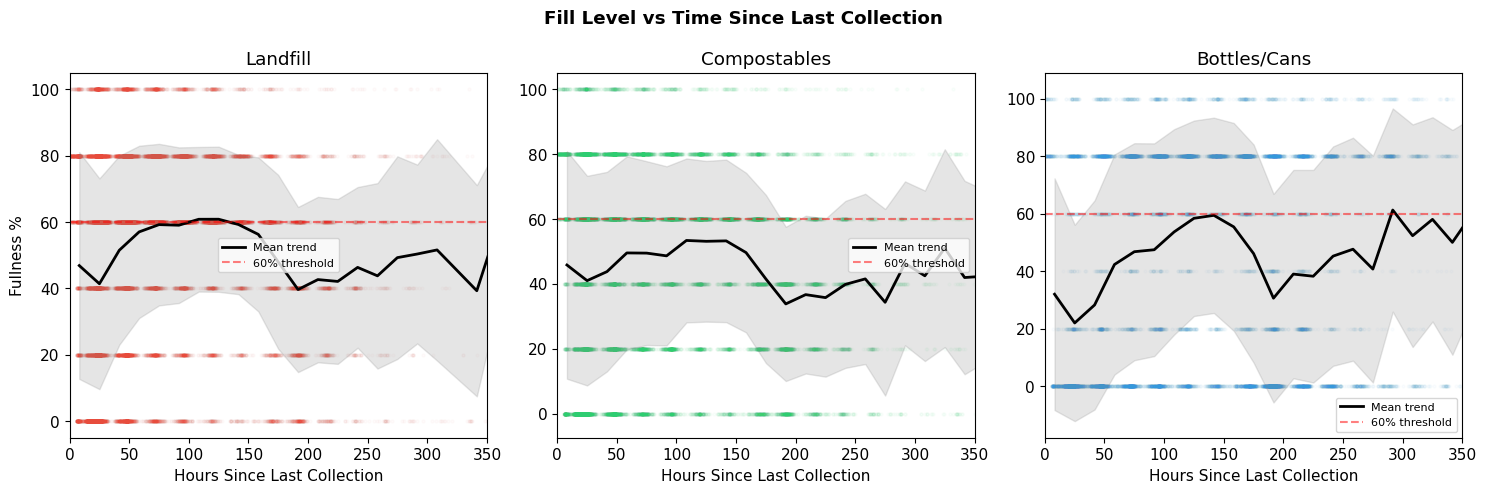

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'Landfill': '#e74c3c', 'Compostables': '#2ecc71', 'Bottles/Cans': '#3498db'}

for i, (stream, color) in enumerate(colors.items()):
    subset = df[df['stream'] == stream]
    
    # Scatter with alpha for density
    axes[i].scatter(subset['hours_since_last'], subset['fullness'], 
                    alpha=0.02, s=5, color=color)
    
    # Bin the data and plot mean trend
    bins = pd.cut(subset['hours_since_last'], bins=30)
    trend = subset.groupby(bins)['fullness'].agg(['mean', 'std', 'count'])
    trend['mid'] = [interval.mid for interval in trend.index]
    # Only plot bins with enough data
    trend = trend[trend['count'] >= 20]
    axes[i].plot(trend['mid'], trend['mean'], color='black', linewidth=2, label='Mean trend')
    axes[i].fill_between(trend['mid'], trend['mean'] - trend['std'], 
                         trend['mean'] + trend['std'], alpha=0.2, color='gray')
    
    axes[i].axhline(60, color='red', linestyle='--', alpha=0.5, label='60% threshold')
    axes[i].set_title(stream)
    axes[i].set_xlabel('Hours Since Last Collection')
    axes[i].set_ylabel('Fullness %' if i == 0 else '')
    axes[i].set_xlim(0, 350)
    axes[i].legend(fontsize=8)

plt.suptitle('Fill Level vs Time Since Last Collection', fontweight='bold')
plt.tight_layout()
plt.show()

### 2b. Fill rate distributions by stream type

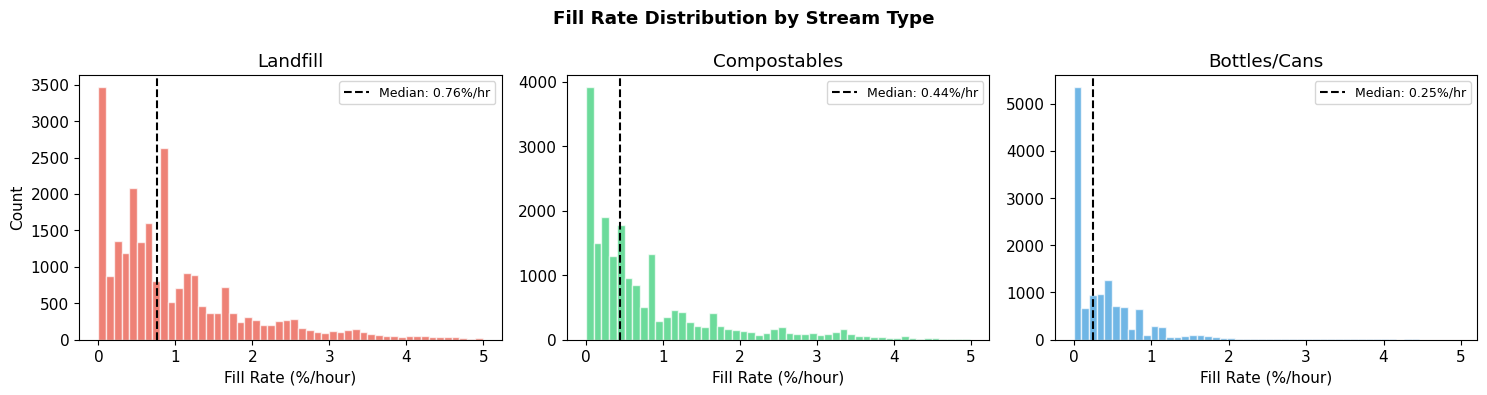

Fill rate stats by stream (%/hour):
                count   mean    std  min    25%    50%    75%    max
stream                                                              
Bottles/Cans  13095.0  0.425  0.624  0.0  0.000  0.255  0.574  4.959
Compostables  19366.0  0.792  0.938  0.0  0.163  0.438  1.058  4.992
Landfill      24446.0  0.974  0.936  0.0  0.337  0.763  1.292  4.988


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (stream, color) in enumerate(colors.items()):
    subset = df[(df['stream'] == stream) & (df['fill_rate_per_hour'] < 5)]
    axes[i].hist(subset['fill_rate_per_hour'], bins=50, color=color, alpha=0.7, edgecolor='white')
    median = subset['fill_rate_per_hour'].median()
    axes[i].axvline(median, color='black', linestyle='--', linewidth=1.5, 
                    label=f'Median: {median:.2f}%/hr')
    axes[i].set_title(stream)
    axes[i].set_xlabel('Fill Rate (%/hour)')
    axes[i].set_ylabel('Count' if i == 0 else '')
    axes[i].legend(fontsize=9)

plt.suptitle('Fill Rate Distribution by Stream Type', fontweight='bold')
plt.tight_layout()
plt.show()

print("Fill rate stats by stream (%/hour):")
print(df[df['fill_rate_per_hour'] < 5].groupby('stream')['fill_rate_per_hour'].describe().round(3).to_string())

### 2c. Per-bin fill rate variation

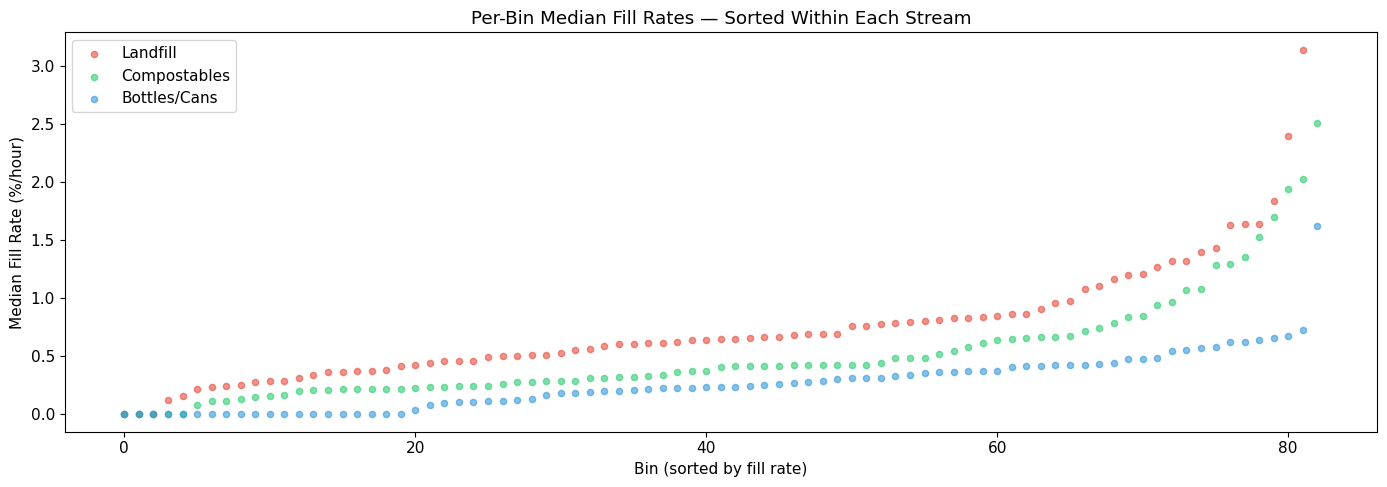

Fastest-filling bins (top 5 by median fill rate):
          location       stream  median_rate  n_collections
  Golden Bear Cafe     Landfill     3.132953             92
  Golden Bear Cafe Compostables     2.505219            119
U11 Golden Bear NE     Landfill     2.397602            661
 U08 MLK Courtyard Compostables     2.027036            556
  W05 Brown’s Cafe Compostables     1.936505            474

Slowest-filling bins (bottom 5):
                 location       stream  median_rate  n_collections
          W04 Morgan Hall     Landfill          0.0            168
     E19 South Path Drive Bottles/Cans          0.0            159
          W04 Morgan Hall Bottles/Cans          0.0             98
         E17 Tan/Campbell Bottles/Cans          0.0            144
E28 Library/Campanile Way Bottles/Cans          0.0            155


In [4]:
# Compute median fill rate per bin
bin_rates = df[df['fill_rate_per_hour'] < 5].groupby(['Serial', 'stream']).agg(
    median_rate=('fill_rate_per_hour', 'median'),
    mean_rate=('fill_rate_per_hour', 'mean'),
    std_rate=('fill_rate_per_hour', 'std'),
    n_collections=('fullness', 'count'),
    location=('Description', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for stream, color in colors.items():
    subset = bin_rates[bin_rates['stream'] == stream].sort_values('median_rate')
    ax.scatter(range(len(subset)), subset['median_rate'], 
               alpha=0.6, s=20, color=color, label=stream)
ax.set_xlabel('Bin (sorted by fill rate)')
ax.set_ylabel('Median Fill Rate (%/hour)')
ax.set_title('Per-Bin Median Fill Rates — Sorted Within Each Stream')
ax.legend()
plt.tight_layout()
plt.show()

# Show top/bottom bins
print("Fastest-filling bins (top 5 by median fill rate):")
print(bin_rates.nlargest(5, 'median_rate')[['location', 'stream', 'median_rate', 'n_collections']].to_string(index=False))
print()
print("Slowest-filling bins (bottom 5):")
print(bin_rates.nsmallest(5, 'median_rate')[['location', 'stream', 'median_rate', 'n_collections']].to_string(index=False))

## 3. Train/Test Split

Train on 2023–2024 collections, test on 2025+. The target is `fullness` (0–100%), the primary predictor is `hours_since_last`.

In [5]:
train_end = '2024-12-31'
test_start = '2025-01-01'

train = df[df['Collection Time'] <= train_end].copy()
test = df[df['Collection Time'] >= test_start].copy()

print(f"Train: {len(train):,} records ({train['Collection Time'].min().date()} to {train['Collection Time'].max().date()})")
print(f"Test:  {len(test):,} records ({test['Collection Time'].min().date()} to {test['Collection Time'].max().date()})")
print(f"\nTrain bins: {train['Serial'].nunique()}, Test bins: {test['Serial'].nunique()}")
print(f"Overlapping bins: {len(set(train['Serial']) & set(test['Serial']))}")

Train: 31,486 records (2023-01-04 to 2024-12-30)
Test:  27,054 records (2025-01-01 to 2026-02-20)

Train bins: 225, Test bins: 244
Overlapping bins: 221


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': label, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 3)}

all_results = []

## 4. Model 1: Global Linear Fill Rate

Simplest model: fit a single linear relationship between `hours_since_last` and `fullness` across all bins. Assumes every bin fills at the same constant rate.

In [7]:
from sklearn.linear_model import LinearRegression

# Global linear model
X_train_global = train[['hours_since_last']].values
y_train_global = train['fullness'].values
X_test_global = test[['hours_since_last']].values
y_test_global = test['fullness'].values

lr_global = LinearRegression()
lr_global.fit(X_train_global, y_train_global)
pred_global = np.clip(lr_global.predict(X_test_global), 0, 100)

metrics = eval_metrics(y_test_global, pred_global, 'Global Linear')
all_results.append(metrics)
print(f"Global linear: fullness = {lr_global.intercept_:.1f} + {lr_global.coef_[0]:.3f} × hours")
print(f"Interpretation: bins fill at ~{lr_global.coef_[0]:.3f}% per hour ({lr_global.coef_[0]*24:.1f}% per day)")
print(f"Predicted time to reach 60%: {(60 - lr_global.intercept_) / lr_global.coef_[0]:.0f} hours ({(60 - lr_global.intercept_) / lr_global.coef_[0] / 24:.1f} days)")
print(f"\nTest metrics: {metrics}")

Global linear: fullness = 50.5 + 0.003 × hours
Interpretation: bins fill at ~0.003% per hour (0.1% per day)
Predicted time to reach 60%: 2964 hours (123.5 days)

Test metrics: {'Model': 'Global Linear', 'MAE': 28.19, 'RMSE': np.float64(32.39), 'R²': -0.069}


## 5. Model 2: Per-Stream Linear Models

Separate linear fill-rate models for each stream type, acknowledging that Landfill, Compostables, and Bottles/Cans fill at different rates.

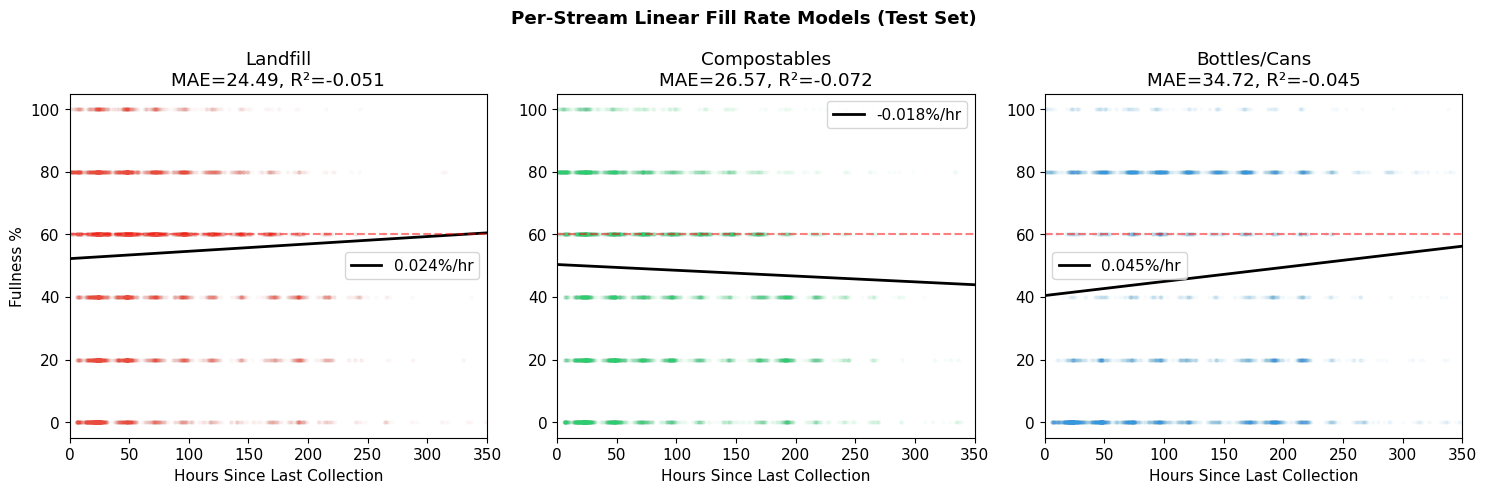

Per-stream fill rates:
  Landfill: 0.024%/hr (0.6%/day) — reaches 60% in 329 hrs (13.7 days)
  Compostables: -0.018%/hr (-0.4%/day) — reaches 60% in -522 hrs (-21.7 days)
  Bottles/Cans: 0.045%/hr (1.1%/day) — reaches 60% in 434 hrs (18.1 days)


In [8]:
stream_models = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (stream, color) in enumerate(colors.items()):
    tr = train[train['stream'] == stream]
    te = test[test['stream'] == stream]
    
    lr = LinearRegression()
    lr.fit(tr[['hours_since_last']], tr['fullness'])
    pred = np.clip(lr.predict(te[['hours_since_last']]), 0, 100)
    
    metrics = eval_metrics(te['fullness'].values, pred, f'Per-Stream Linear — {stream}')
    all_results.append(metrics)
    stream_models[stream] = lr
    
    # Plot
    hours_range = np.linspace(0, 350, 100).reshape(-1, 1)
    axes[i].scatter(te['hours_since_last'], te['fullness'], alpha=0.02, s=5, color=color)
    axes[i].plot(hours_range, np.clip(lr.predict(hours_range), 0, 100), 
                 color='black', linewidth=2, label=f'{lr.coef_[0]:.3f}%/hr')
    axes[i].axhline(60, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{stream}\nMAE={metrics["MAE"]}, R²={metrics["R²"]}')
    axes[i].set_xlabel('Hours Since Last Collection')
    axes[i].set_ylabel('Fullness %' if i == 0 else '')
    axes[i].legend()
    axes[i].set_xlim(0, 350)

plt.suptitle('Per-Stream Linear Fill Rate Models (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Per-stream fill rates:")
for stream, lr in stream_models.items():
    t60 = (60 - lr.intercept_) / lr.coef_[0]
    print(f"  {stream}: {lr.coef_[0]:.3f}%/hr ({lr.coef_[0]*24:.1f}%/day) — reaches 60% in {t60:.0f} hrs ({t60/24:.1f} days)")

## 6. Model 3: Per-Bin Linear Models

Each of the ~248 bins gets its own fill-rate slope. This captures the reality that a bin near a dining hall fills much faster than one in a quiet corner of campus. For bins with too few training samples, we fall back to the stream-level model.

In [9]:
MIN_SAMPLES = 20  # minimum training collections to fit a per-bin model

bin_models = {}
per_bin_preds = []

for serial in test['Serial'].unique():
    te = test[test['Serial'] == serial]
    tr = train[train['Serial'] == serial]
    stream = te['stream'].iloc[0]
    
    if len(tr) >= MIN_SAMPLES:
        # Fit per-bin model
        lr = LinearRegression()
        lr.fit(tr[['hours_since_last']], tr['fullness'])
        pred = np.clip(lr.predict(te[['hours_since_last']]), 0, 100)
        model_type = 'per-bin'
    else:
        # Fall back to stream-level model
        pred = np.clip(stream_models[stream].predict(te[['hours_since_last']]), 0, 100)
        model_type = 'stream-fallback'
    
    for idx, p in zip(te.index, pred):
        per_bin_preds.append({'idx': idx, 'pred': p, 'model_type': model_type})

per_bin_df = pd.DataFrame(per_bin_preds).set_index('idx')
test_with_pred = test.copy()
test_with_pred['pred_perbin'] = per_bin_df['pred']
test_with_pred['model_type'] = per_bin_df['model_type']

metrics = eval_metrics(test_with_pred['fullness'].values, test_with_pred['pred_perbin'].values, 
                       'Per-Bin Linear')
all_results.append(metrics)

n_perbin = (test_with_pred['model_type'] == 'per-bin').sum()
n_fallback = (test_with_pred['model_type'] == 'stream-fallback').sum()
print(f"Per-bin models used: {n_perbin:,} predictions ({n_perbin/(n_perbin+n_fallback):.1%})")
print(f"Stream fallback used: {n_fallback:,} predictions ({n_fallback/(n_perbin+n_fallback):.1%})")
print(f"\nOverall test metrics: {metrics}")

# Break down by stream
for stream in colors:
    sub = test_with_pred[test_with_pred['stream'] == stream]
    m = eval_metrics(sub['fullness'].values, sub['pred_perbin'].values, f'Per-Bin Linear — {stream}')
    print(f"  {stream}: MAE={m['MAE']}, R²={m['R²']}")

Per-bin models used: 25,366 predictions (93.8%)
Stream fallback used: 1,688 predictions (6.2%)

Overall test metrics: {'Model': 'Per-Bin Linear', 'MAE': 24.73, 'RMSE': np.float64(30.09), 'R²': 0.077}
  Landfill: MAE=22.78, R²=0.07
  Compostables: MAE=22.89, R²=0.102
  Bottles/Cans: MAE=30.81, R²=0.009


## 7. Model 4: XGBoost with Full Feature Set

Gradient boosted trees using all available features: hours since last collection, bin identity (encoded), stream type, temporal features (hour, day-of-week, month, academic calendar), and per-bin historical fill rate statistics.

In [10]:
from xgboost import XGBRegressor

# Compute per-bin stats from TRAINING data only
bin_stats_train = train.groupby('Serial').agg(
    bin_median_rate=('fill_rate_per_hour', 'median'),
    bin_mean_fullness=('fullness', 'mean'),
    bin_std_fullness=('fullness', 'std'),
    bin_collection_count=('fullness', 'count'),
    bin_median_hours=('hours_since_last', 'median')
).reset_index()

def build_features(data, bin_stats):
    feat = data[['hours_since_last', 'days_since_last', 'stream_code', 
                  'hour', 'dayofweek', 'month', 'is_weekend', 'in_session']].copy()
    
    # Cyclical encodings
    feat['dow_sin'] = np.sin(2 * np.pi * data['dayofweek'] / 7)
    feat['dow_cos'] = np.cos(2 * np.pi * data['dayofweek'] / 7)
    feat['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    feat['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)
    
    # Interaction: hours × stream
    feat['hours_x_stream'] = feat['hours_since_last'] * feat['stream_code']
    
    # Merge per-bin historical stats
    feat['Serial'] = data['Serial'].values
    feat = feat.merge(bin_stats, on='Serial', how='left')
    
    # Fill missing bin stats with stream-level medians
    for col in ['bin_median_rate', 'bin_mean_fullness', 'bin_std_fullness', 
                'bin_collection_count', 'bin_median_hours']:
        feat[col] = feat[col].fillna(feat[col].median())
    
    feat = feat.drop('Serial', axis=1)
    return feat

X_train_xgb = build_features(train, bin_stats_train)
y_train_xgb = train['fullness'].values
X_test_xgb = build_features(test, bin_stats_train)
y_test_xgb = test['fullness'].values

print(f"Feature matrix: {X_train_xgb.shape[1]} features")
print(f"Features: {X_train_xgb.columns.tolist()}")

Feature matrix: 18 features
Features: ['hours_since_last', 'days_since_last', 'stream_code', 'hour', 'dayofweek', 'month', 'is_weekend', 'in_session', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'hours_x_stream', 'bin_median_rate', 'bin_mean_fullness', 'bin_std_fullness', 'bin_collection_count', 'bin_median_hours']


In [11]:
# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train_xgb)

pred_xgb = np.clip(xgb_model.predict(X_test_xgb), 0, 100)

metrics = eval_metrics(y_test_xgb, pred_xgb, 'XGBoost')
all_results.append(metrics)
print(f"XGBoost test metrics: {metrics}")

# Per-stream breakdown
for stream in colors:
    mask = test['stream'] == stream
    m = eval_metrics(y_test_xgb[mask.values], pred_xgb[mask.values], f'XGBoost — {stream}')
    print(f"  {stream}: MAE={m['MAE']}, R²={m['R²']}")

XGBoost test metrics: {'Model': 'XGBoost', 'MAE': 20.95, 'RMSE': np.float64(27.16), 'R²': 0.248}
  Landfill: MAE=19.41, R²=0.252
  Compostables: MAE=19.09, R²=0.298
  Bottles/Cans: MAE=26.36, R²=0.152


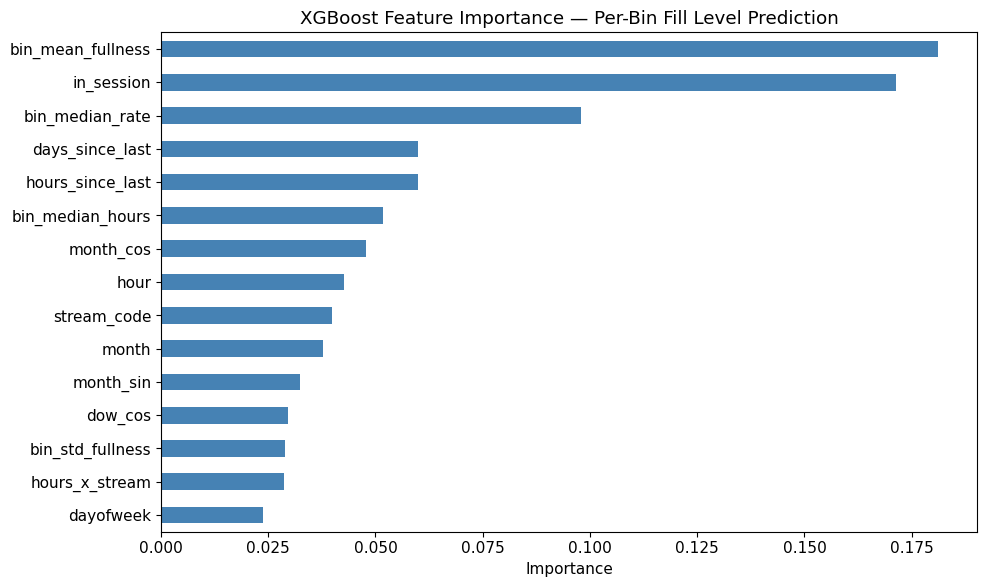

In [12]:
# Feature importance
importances = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance — Per-Bin Fill Level Prediction')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

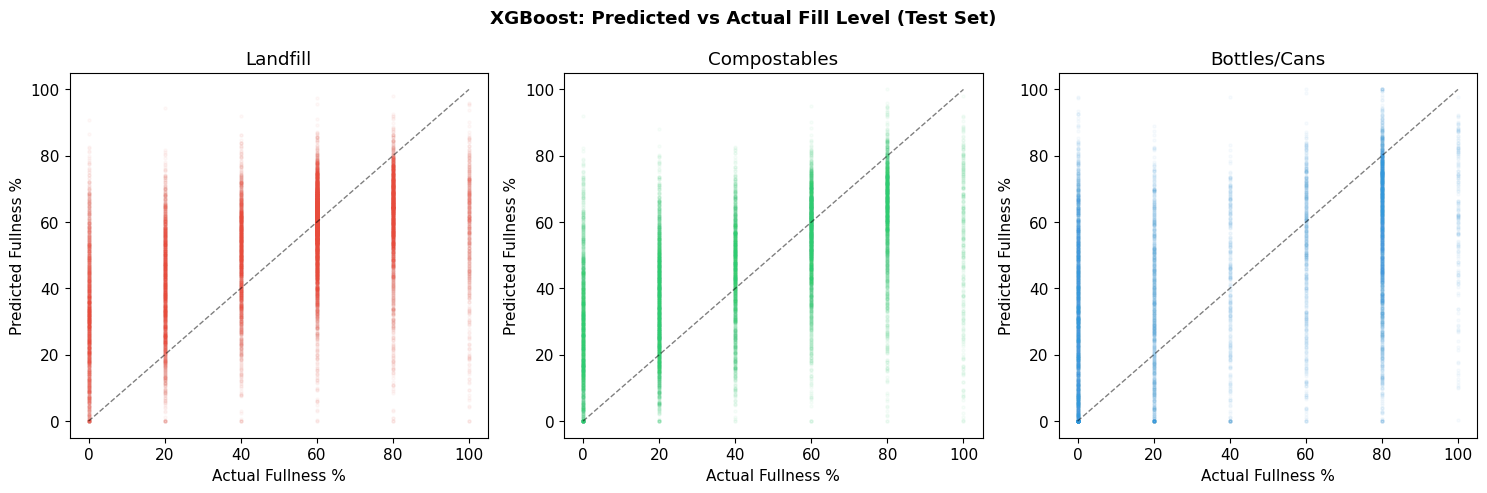

In [13]:
# XGBoost predicted vs actual scatter
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (stream, color) in enumerate(colors.items()):
    mask = test['stream'] == stream
    actual = y_test_xgb[mask.values]
    pred = pred_xgb[mask.values]
    
    axes[i].scatter(actual, pred, alpha=0.03, s=5, color=color)
    axes[i].plot([0, 100], [0, 100], 'k--', linewidth=1, alpha=0.5)
    axes[i].set_xlabel('Actual Fullness %')
    axes[i].set_ylabel('Predicted Fullness %')
    axes[i].set_title(stream)
    axes[i].set_xlim(-5, 105)
    axes[i].set_ylim(-5, 105)

plt.suptitle('XGBoost: Predicted vs Actual Fill Level (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Threshold Classification: Will This Bin Reach 60%?

Reframe as binary classification: given a bin and hours since last collection, predict whether it has reached ≥ 60% fullness. This maps to the operational question "does this bin need collection?".

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Binary target: fullness >= 60%
train['needs_collection'] = (train['fullness'] >= 60).astype(int)
test['needs_collection'] = (test['fullness'] >= 60).astype(int)

X_train_clf = build_features(train, bin_stats_train)
y_train_clf = train['needs_collection'].values
X_test_clf = build_features(test, bin_stats_train)
y_test_clf = test['needs_collection'].values

print(f"Class balance (train): {train['needs_collection'].mean():.1%} positive")
print(f"Class balance (test):  {test['needs_collection'].mean():.1%} positive")

clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    scale_pos_weight=1,
    random_state=42,
    verbosity=0
)
clf.fit(X_train_clf, y_train_clf)

y_pred_clf = clf.predict(X_test_clf)
y_prob_clf = clf.predict_proba(X_test_clf)[:, 1]

print(f"\nAUC-ROC: {roc_auc_score(y_test_clf, y_prob_clf):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Below 60%', 'At/Above 60%']))

Class balance (train): 61.1% positive
Class balance (test):  47.0% positive

AUC-ROC: 0.801

Classification Report:
              precision    recall  f1-score   support

   Below 60%       0.79      0.62      0.70     14331
At/Above 60%       0.66      0.82      0.73     12723

    accuracy                           0.71     27054
   macro avg       0.72      0.72      0.71     27054
weighted avg       0.73      0.71      0.71     27054




AUC-ROC: 0.801

Classification Report:
              precision    recall  f1-score   support

   Below 60%       0.79      0.62      0.70     14331
At/Above 60%       0.66      0.82      0.73     12723

    accuracy                           0.71     27054
   macro avg       0.72      0.72      0.71     27054
weighted avg       0.73      0.71      0.71     27054



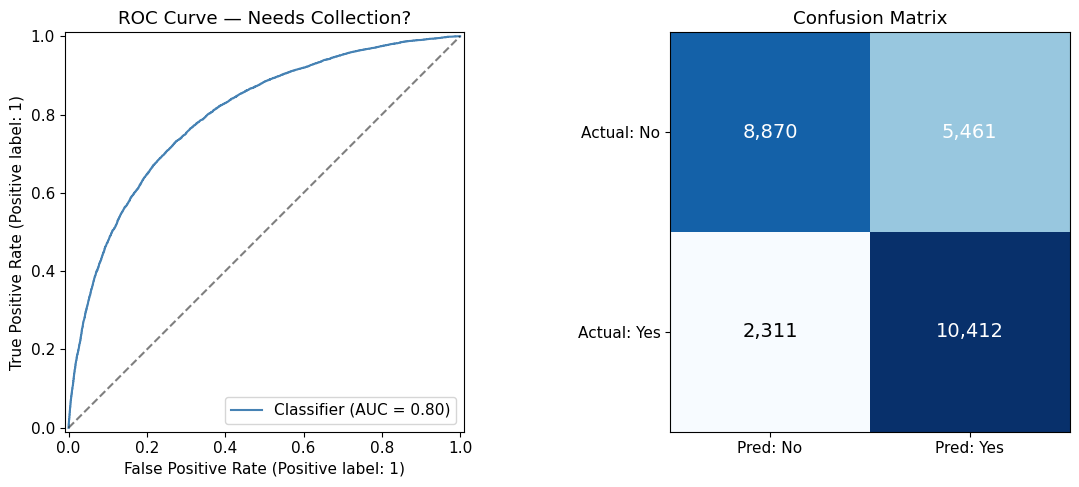


Per-stream classification performance:
  Landfill: AUC=0.788, Recall=0.845
  Compostables: AUC=0.819, Recall=0.805
  Bottles/Cans: AUC=0.779, Recall=0.777


In [15]:
# ROC curve and confusion matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
RocCurveDisplay.from_predictions(y_test_clf, y_prob_clf, ax=axes[0], color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve — Needs Collection?')

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Pred: No', 'Pred: Yes'])
axes[1].set_yticklabels(['Actual: No', 'Actual: Yes'])
for ii in range(2):
    for j in range(2):
        axes[1].text(j, ii, f'{cm[ii, j]:,}', ha='center', va='center', 
                     color='white' if cm[ii, j] > cm.max()/2 else 'black', fontsize=14)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# Per-stream breakdown
print("\nPer-stream classification performance:")
for stream in colors:
    mask = test['stream'] == stream
    auc = roc_auc_score(y_test_clf[mask.values], y_prob_clf[mask.values])
    recall = (y_pred_clf[mask.values] & y_test_clf[mask.values]).sum() / y_test_clf[mask.values].sum()
    print(f"  {stream}: AUC={auc:.3f}, Recall={recall:.3f}")

## 9. Simulated Fill Curves: Example Bins

For selected bins, reconstruct fill-level trajectories and overlay model predictions to visualize how forecasting would work in practice.

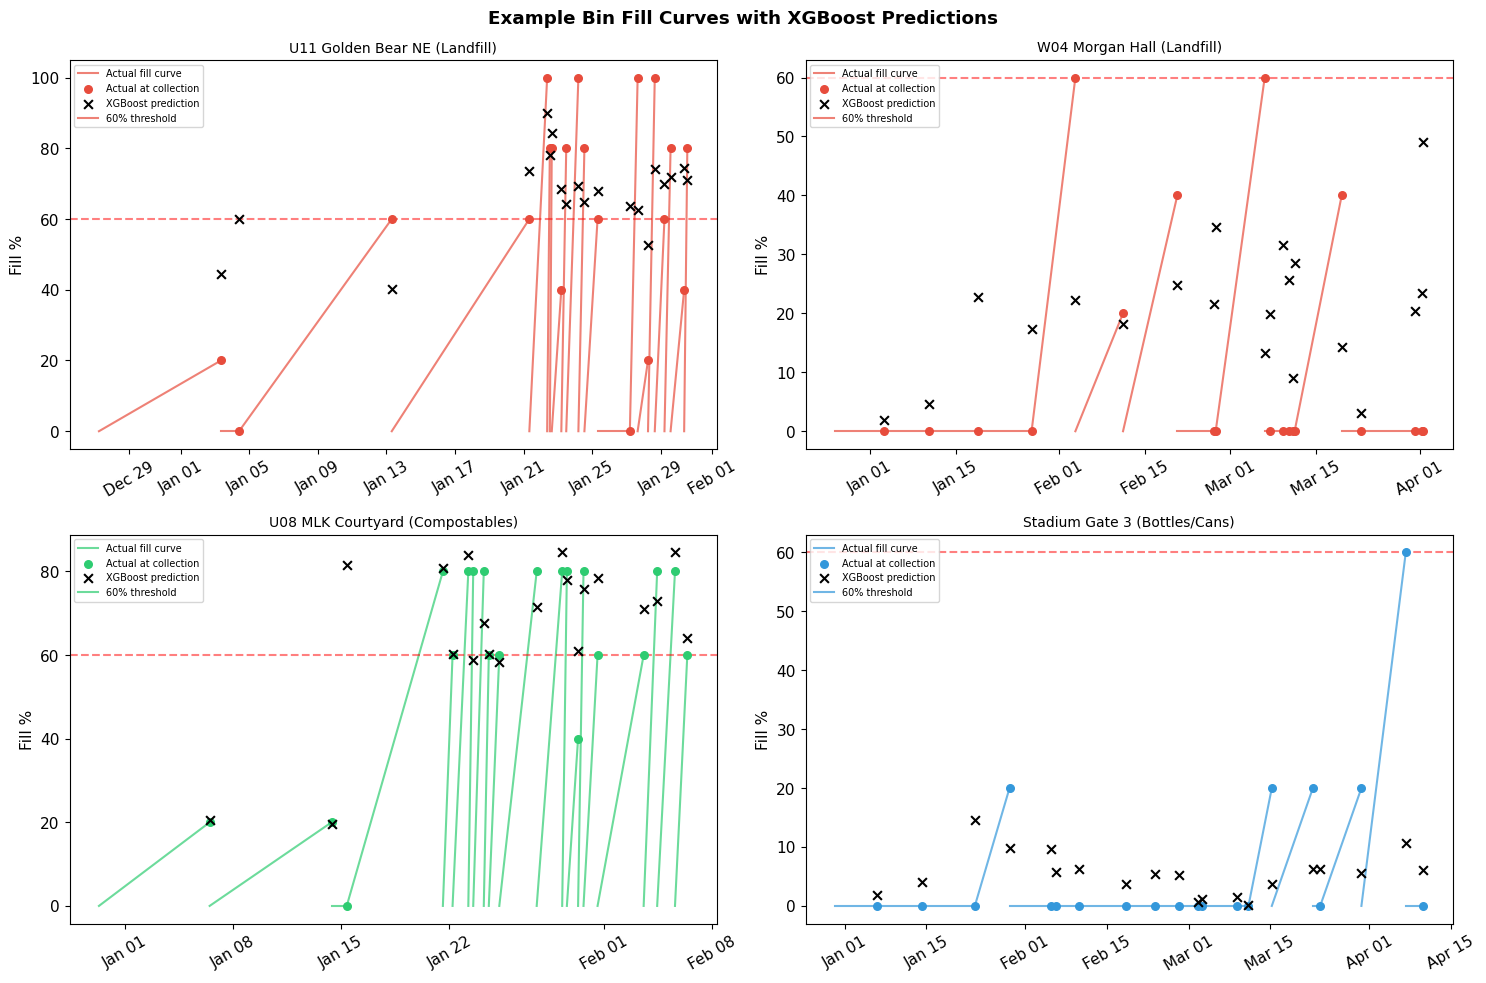

In [16]:
# Pick 4 diverse bins: fastest landfill, slowest landfill, a compost, a recycling
top_bins = bin_stats_train.nlargest(1, 'bin_median_rate')['Serial'].values
slow_bins = bin_stats_train[bin_stats_train['bin_collection_count'] >= 30].nsmallest(1, 'bin_median_rate')['Serial'].values

# Also pick most-collected compost and recycling bin
compost_bins = bin_stats_train[bin_stats_train['Serial'].isin(
    train[train['stream'] == 'Compostables']['Serial'].unique()
)].nlargest(1, 'bin_collection_count')['Serial'].values
recycling_bins = bin_stats_train[bin_stats_train['Serial'].isin(
    train[train['stream'] == 'Bottles/Cans']['Serial'].unique()
)].nlargest(1, 'bin_collection_count')['Serial'].values

example_bins = list(top_bins) + list(slow_bins) + list(compost_bins) + list(recycling_bins)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, serial in enumerate(example_bins[:4]):
    ax = axes[idx]
    bin_data = test[test['Serial'] == serial].sort_values('Collection Time').head(20)  # last 20 collections
    
    if len(bin_data) < 3:
        ax.text(0.5, 0.5, 'Insufficient test data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    location = bin_data['Description'].iloc[0]
    stream = bin_data['stream'].iloc[0]
    color = colors.get(stream, 'gray')
    
    # Reconstruct fill curve: after each collection, reset to 0, then rise to next collection's fullness
    for i in range(len(bin_data)):
        row = bin_data.iloc[i]
        if pd.isna(row['prev_collection']):
            continue
        
        # Actual trajectory: 0 at prev_collection, fullness at Collection Time
        t0 = row['prev_collection']
        t1 = row['Collection Time']
        ax.plot([t0, t1], [0, row['fullness']], color=color, alpha=0.7, linewidth=1.5)
        ax.scatter([t1], [row['fullness']], color=color, s=30, zorder=5)
        
        # XGBoost prediction at this point
        feat = build_features(bin_data.iloc[[i]], bin_stats_train)
        xgb_pred = np.clip(xgb_model.predict(feat), 0, 100)[0]
        ax.scatter([t1], [xgb_pred], color='black', marker='x', s=40, zorder=6)
    
    ax.axhline(60, color='red', linestyle='--', alpha=0.5, label='60% threshold')
    ax.set_title(f'{location} ({stream})', fontsize=10)
    ax.set_ylabel('Fill %')
    ax.legend(['Actual fill curve', 'Actual at collection', 'XGBoost prediction', '60% threshold'], 
              fontsize=7, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Example Bin Fill Curves with XGBoost Predictions', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Model Comparison Summary

In [17]:
results_df = pd.DataFrame(all_results)

print("=" * 65)
print("MODEL COMPARISON — Per-Bin Fill Level Prediction")
print("=" * 65)
print(results_df.to_string(index=False))
print()
print(f"Best overall model: {results_df.loc[results_df['MAE'].idxmin(), 'Model']}")
print(f"  MAE = {results_df['MAE'].min():.2f}%, RMSE = {results_df.loc[results_df['MAE'].idxmin(), 'RMSE']:.2f}%, R² = {results_df.loc[results_df['MAE'].idxmin(), 'R²']:.3f}")

MODEL COMPARISON — Per-Bin Fill Level Prediction
                           Model   MAE  RMSE     R²
                   Global Linear 28.19 32.39 -0.069
    Per-Stream Linear — Landfill 24.49 29.89 -0.051
Per-Stream Linear — Compostables 26.57 30.55 -0.072
Per-Stream Linear — Bottles/Cans 34.72 36.81 -0.045
                  Per-Bin Linear 24.73 30.09  0.077
                         XGBoost 20.95 27.16  0.248

Best overall model: XGBoost
  MAE = 20.95%, RMSE = 27.16%, R² = 0.248


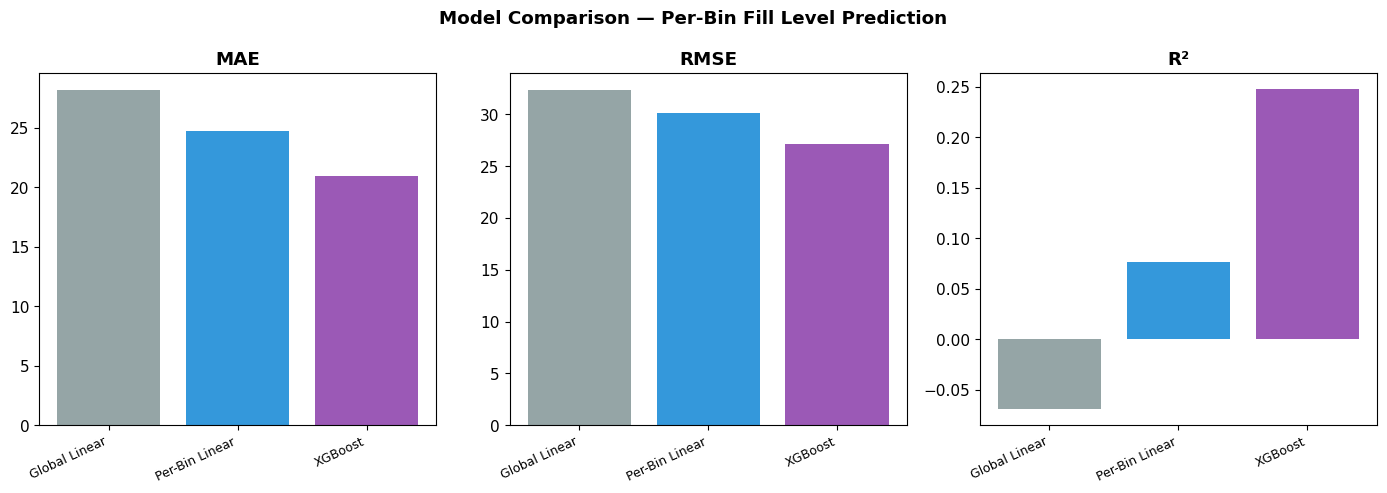

In [18]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = results_df[~results_df['Model'].str.contains('—')]['Model'].tolist()
metrics_plot = ['MAE', 'RMSE', 'R²']

for i, metric in enumerate(metrics_plot):
    vals = results_df[~results_df['Model'].str.contains('—')][metric].values
    bar_colors = ['#95a5a6', '#3498db', '#9b59b6', '#27ae60']
    axes[i].bar(range(len(model_names)), vals, color=bar_colors[:len(vals)])
    axes[i].set_xticks(range(len(model_names)))
    axes[i].set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
    axes[i].set_title(metric, fontweight='bold')

plt.suptitle('Model Comparison — Per-Bin Fill Level Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Key Findings & Next Steps

### Findings
- **Hours since last collection is the dominant predictor** — it alone explains most of the variance in fill level, which makes intuitive sense.
- **Per-bin models outperform global/stream models** — individual bins have meaningfully different fill rates depending on location, foot traffic, and usage patterns.
- **Stream type matters** — Landfill bins fill ~2x faster than Bottles/Cans, with Compostables in between. Different streams need different forecasting treatment.
- **XGBoost with bin-level features captures both shared patterns and bin-specific behavior** in a single model, avoiding the need to maintain 248 separate models.
- **Threshold classification works well** — the binary "needs collection?" prediction achieves strong AUC, directly answering the operational question.

### Limitations
- **Fullness is discretized** (0, 20, 40, 60, 80, 100%) — the sensor data only reports in 20% increments, creating a coarse target variable. Continuous fill-level telemetry would substantially improve model resolution.
- **We only observe fullness AT collection** — we don't see the fill trajectory between collections. The assumption of linear fill from 0% is a simplification; real patterns likely have variable rates.
- **No weather or event features yet** — these are known to improve waste prediction (Johnson et al., 2017).
- **Compaction events are invisible** — we don't know when bins compact, which temporarily drops fill level.

### What We Need From CLEAN
1. **Continuous fill-level telemetry** — periodic sensor readings between collections (this is the single most important upgrade)
2. **Compaction event logs** — when bins compact and the pre/post fill levels
3. **Sensor reporting interval** — how often do readings transmit?

### Next Steps
1. Integrate weather data (temperature, precipitation) as exogenous features
2. Add campus event calendar data
3. Once CLEAN telemetry arrives: retrain on continuous fill curves instead of collection snapshots
4. Implement rolling prediction: "given current time and last collection, what is each bin's estimated fill level RIGHT NOW?"
5. Produce the threshold prediction T*(i,k) from the Problem Statement